---
title: "Multilevel Regression and Post-Stratification"
subtitle: "Weighting as a Corrective for Biased Samples"
author: "Nathaniel Forde"
date: today
format:
  html:
    theme: cosmo
    toc: true
    toc-depth: 3
    toc-location: left
    code-fold: false
    code-tools: true
    number-sections: true
    fig-width: 10
    fig-height: 6
execute:
  warning: false
  message: false
bibliography: references.bib
jupyter: applied-bayesian-regression-modeling-env
embed-resources: true
keep-ipynb: true
---

In [1]:
#| echo: false
#| include: false
import warnings
warnings.filterwarnings('ignore')

# Introduction: Weighting as a Corrective

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** why regression models automatically perform stratification, and why this is insufficient when samples are non-representative
2. **Identify** the sources and consequences of sampling bias in survey data
3. **Construct** a deliberate bias scenario to test MRP corrections
4. **Specify** multilevel regression models with random intercepts and interactions using Bambi
5. **Implement** post-stratification by reweighting posterior predictions with census population counts
6. **Evaluate** MRP-corrected estimates against census ground truth
7. **Assess** the conditions under which MRP is most and least effective

## The Central Insight

What are we really doing when we fit a regression model? A question that arises when first learning the tools of the trade, and arises again when debugging the strange results of your thousandth logistic regression. We take the view that **regression is stratification automated**: a regression model computes stratum-specific conditional effects and combines them, weighted by the prevalence of each stratum *in the sample data*. This is simultaneously regression's great power and its great vulnerability.

When the sample reflects the population, regression gives us the right answer. When the sample is biased --- and samples are almost always biased in some direction --- regression faithfully adjusts to the *wrong* weights. The model doesn't know or care whether its training data is representative.

**Multilevel Regression and Post-Stratification (MRP)** is the corrective. The idea is beautifully simple: fit a model to learn how outcomes vary across demographic groups, then re-assemble the predictions using the *population's* demographic weights rather than the *sample's*. This notebook walks through the entire MRP workflow, from motivating example through implementation and evaluation.

## The Unifying Identity

Every method in this notebook is a special case of the **law of total expectation**:

$$E[Y] = \sum_{j} P(\text{cell}_j) \cdot E[Y \mid \text{cell}_j]$$

This identity decomposes a population-level quantity into two ingredients: *how people in each cell behave* ($E[Y \mid \text{cell}_j]$) and *how prevalent each cell is* ($P(\text{cell}_j)$). The methods we encounter through this notebook differ only in how they estimate these two pieces:

| Method | $E[Y \mid \text{cell}_j]$ | $P(\text{cell}_j)$ |
|:---|:---|:---|
| **Manual stratification** | Raw group means | Hand-computed shares |
| **Regression** | Model-estimated conditional means | *Implicit*: sample proportions |
| **Survey weighting / raking** | Raw group means | Census / design weights |
| **MRP** | Model-smoothed estimates (partial pooling) | Census population shares |

Read left to right, the table tells you what each method does. Read top to bottom, it tells a story of progressive refinement: from manual calculation, to model-assisted estimation, to model-assisted estimation *with* corrected weights. MRP sits at the end of this progression --- it combines the best available estimate of cell-level behaviour with the best available knowledge of cell-level prevalence. It is not a separate technique bolted onto regression; it is the natural completion of the logic that regression already embodies.

## Basu's Elephant

::: {.callout-note}
### The Parable

The statistician Debabrata Basu told a story about weighing elephants in a circus [@basu1971essay]. Asked to estimate the average weight, the statistician was offered free choice of which elephants to weigh. Naturally, the friendliest and most accessible animals were selected. The estimate was wildly wrong --- the docile elephants happened to be the smallest.

The moral: **cooperation is not representativeness**. Who responds to your survey is not random, and the pattern of non-response carries information about the quantity you're trying to measure. Basu's parable reminds us that the *sampling mechanism* matters as much as the *measurement instrument*. A perfectly calibrated scale applied to a biased sample still produces a biased estimate.

This is the problem MRP was designed to solve. Even if we cannot control who responds to our survey, we can correct our estimates using external knowledge about the population's composition.
:::


In [2]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Regression as Stratification

The connection between regression and stratification is fundamental and often underappreciated. To make it concrete, we begin with a small, fully transparent example before scaling up to the real-world application.

## The Heart Transplant Example

Consider this dataset of heart transplant patients, adapted from Hernán and Robins' *Causal Inference: What If* [@hernan2020causal]. We have 20 patients with binary indicators for treatment status, risk level, and outcome (death).


In [3]:
df = pd.DataFrame(
    {
        "name": [
            "Rheia", "Kronos", "Demeter", "Hades", "Hestia", "Poseidon",
            "Hera", "Zeus", "Artemis", "Apollo", "Leto", "Ares",
            "Athena", "Hephaestus", "Aphrodite", "Cyclope", "Persephone",
            "Hermes", "Hebe", "Dionysus",
        ],
        "Risk_Strata": [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        "Treatment": [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        "Outcome": [0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    }
)

df["Treatment_x_Risk_Strata"] = df.Treatment * df.Risk_Strata
df

,name,Risk_Strata,Treatment,Outcome,Treatment_x_Risk_Strata
0,Rheia,0,0,0,0
1,Kronos,0,0,1,0
2,Demeter,0,0,0,0
3,Hades,0,0,0,0
4,Hestia,0,1,0,0
5,Poseidon,0,1,0,0
6,Hera,0,1,0,0
7,Zeus,0,1,1,0
8,Artemis,1,0,1,0
9,Apollo,1,0,1,0


If treatment assignment were completely randomised, we'd expect a reasonable balance of risk levels across treated and untreated groups. Computing a simple average, the treated group appears to do *worse*:


In [4]:
simple_average = (
    df.groupby("Treatment")[["Outcome"]]
    .mean()
    .rename({"Outcome": "Share"}, axis=1)
)
simple_average

,Share
Treatment,
0,0.428571
1,0.538462


This suggests an alarming causal effect: treatment seems to *increase* the risk of death.


In [5]:
causal_risk_ratio = simple_average.iloc[1]["Share"] / simple_average.iloc[0]["Share"]
print(f"Naive Causal Risk Ratio: {causal_risk_ratio:.2f}")

Naive Causal Risk Ratio: 1.26


## Stratification Dissolves the Paradox

The paradox is driven by an imbalance in risk levels across treatment groups. High-risk patients are disproportionately assigned treatment:


In [6]:
df.groupby("Risk_Strata")[["Treatment"]].count().assign(
    proportion=lambda x: x["Treatment"] / len(df)
)

,Treatment,proportion
Risk_Strata,,
0,8,0.4
1,12,0.6


When we condition on risk stratum --- looking at the effect of treatment *within* each risk level --- the paradox vanishes:


In [7]:
outcomes_controlled = (
    df.groupby(["Risk_Strata", "Treatment"])[["Outcome"]]
    .mean()
    .reset_index()
    .pivot(index="Treatment", columns=["Risk_Strata"], values="Outcome")
)
outcomes_controlled

Risk_Strata,0,1
Treatment,,
0,0.25,0.666667
1,0.25,0.666667


Within each stratum, treated and untreated patients have **identical** death rates. The naive comparison was confounded by the unequal distribution of risk levels. We can recover the correct aggregate by weighting each stratum by its population share --- this is the law of total expectation in action, with two strata standing in for the cells:


In [8]:
n_low = (df["Risk_Strata"] == 0).sum() / len(df)
n_high = (df["Risk_Strata"] == 1).sum() / len(df)

weighted_avg = outcomes_controlled.assign(
    weighted_average=lambda x: x[0] * n_low + x[1] * n_high
)
weighted_avg

Risk_Strata,0,1,weighted_average
Treatment,,,
0,0.25,0.666667,0.5
1,0.25,0.666667,0.5


In [9]:
corrected_ratio = (
    weighted_avg.iloc[1]["weighted_average"] / weighted_avg.iloc[0]["weighted_average"]
)
print(f"Corrected Causal Risk Ratio: {corrected_ratio:.2f}")

Corrected Causal Risk Ratio: 1.00


A risk ratio of 1.0 confirms that treatment has no net effect once we properly account for the confounding variable.

## Regression Does This Automatically

The manual stratification above involved grouping, computing conditional means, and weighting. Regression automates all three steps. Compare a naive model (ignoring risk) with a stratified model (controlling for risk and its interaction with treatment):


In [10]:
reg = bmb.Model("Outcome ~ 1 + Treatment", df)
results = reg.fit(random_seed=42)

reg_strata = bmb.Model(
    "Outcome ~ 1 + Treatment + Risk_Strata + Treatment_x_Risk_Strata", df
)
results_strata = reg_strata.fit(random_seed=42)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Treatment]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Treatment, Risk_Strata, Treatment_x_Risk_Strata]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [11]:
az.summary(results, var_names=["Treatment"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Treatment,0.112,0.262,-0.388,0.59,0.004,0.005,3888.0,2375.0,1.0


In [12]:
az.summary(results_strata, var_names=["Treatment"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Treatment,-0.0,0.371,-0.701,0.688,0.008,0.006,2161.0,2415.0,1.0


The treatment effect shrinks toward zero in the stratified model. We can visualise this directly:


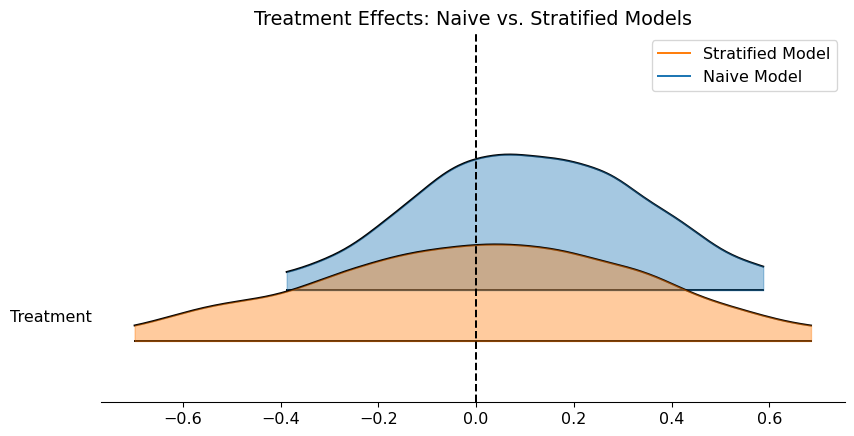

In [13]:
ax = az.plot_forest(
    [results, results_strata],
    model_names=["Naive Model", "Stratified Model"],
    var_names=["Treatment"],
    kind="ridgeplot",
    ridgeplot_alpha=0.4,
    combined=True,
    figsize=(10, 5),
)
ax[0].axvline(0, color="black", linestyle="--")
ax[0].set_title("Treatment Effects: Naive vs. Stratified Models");

::: {.callout-important}
### The Catch

Regression adjusts for the variables you include, weighted by their prevalence **in the sample**. If your sample doesn't reflect the population, the regression will faithfully stratify according to the wrong weights. The model has no way to know that its training data is non-representative.

This is where post-stratification enters.
:::

::: {.callout-note}
### Weighting Was Always There: From OLS to WLS to MRP

The idea that regression involves weighting is not a metaphor --- it is literal. Ordinary least squares minimises $\sum_i (y_i - \hat{y}_i)^2$, which assigns **equal weight** to every observation. This is itself a weighting choice: it assumes each data point is equally informative about the population quantity of interest. When that assumption fails --- because observations have unequal variance, or because some subgroups are over-represented --- the estimates inherit the distortion.

**Weighted least squares** (WLS) makes the weighting explicit: it minimises $\sum_i w_i (y_i - \hat{y}_i)^2$, where $w_i$ can reflect precision (inverse-variance weighting) or sampling design (survey weights). Classical survey statisticians have long used design weights $w_i = 1/\pi_i$ (the inverse of an observation's probability of inclusion) to correct for unequal sampling --- this is the **Horvitz-Thompson** estimator, and it is the direct frequentist ancestor of what MRP does.

The progression is:

1. **OLS**: equal weights (assumes representative sample)
2. **WLS / survey weighting**: observation-level weights correct for known sampling imbalance
3. **MRP**: a model estimates cell-level expectations, then census weights correct the aggregation

Each step refines the same underlying operation --- the weighted sum in the law of total expectation. MRP's contribution is recognising that you can do *both* at once: use a hierarchical model to estimate cell-level quantities well (partial pooling, interactions), and use external population data to weight the aggregation correctly. It is not a departure from regression; it is regression with the weighting made honest.
:::

We can also confirm the adjustment by looking at predicted outcomes under each model. The `plot_predictions` function shows how the stratified model reveals the equal outcomes within risk groups:


Default computed for conditional variable: Treatment


Default computed for conditional variable: Treatment


Default computed for unspecified variable: Risk_Strata, Treatment_x_Risk_Strata


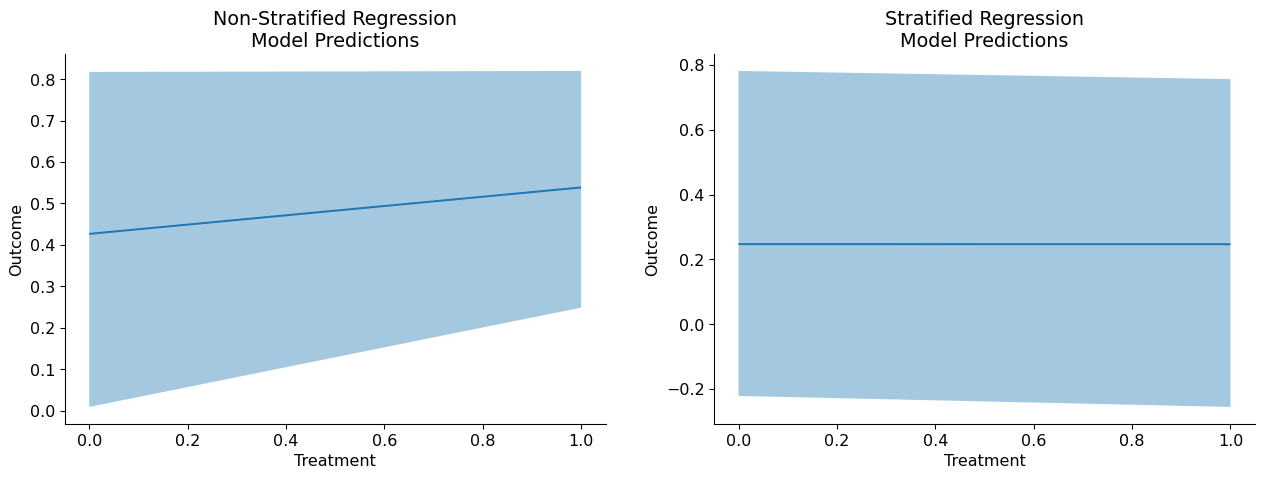

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
bmb.interpret.plot_predictions(reg, results, ["Treatment"], ax=axs[0])
bmb.interpret.plot_predictions(reg_strata, results_strata, ["Treatment"], ax=axs[1])
axs[0].set_title("Non-Stratified Regression\nModel Predictions")
axs[1].set_title("Stratified Regression\nModel Predictions");

# The Need for Post-Stratification

We've established that regression automates stratification within the data it sees. But what if the data itself is skewed? In the context of national surveys, there is always a concern that respondents may not reflect the population across key demographics. It would be hard to put much faith in a survey's accuracy if 90% of respondents were male on a question about the lived experience of women.

Recall the unifying identity: $E[Y] = \sum_j P(\text{cell}_j) \cdot E[Y \mid \text{cell}_j]$. Regression gives us good estimates of the conditional expectations $E[Y \mid \text{cell}_j]$, but it uses the *sample's* cell proportions $P_{\text{sample}}(\text{cell}_j)$ for aggregation. When we know that these sample proportions are wrong, we can substitute the *census* proportions instead. This is Multilevel Regression and Post-Stratification (MRP), a technique widely applied in political polling, market research, public health estimation, and beyond [@park2004bayesian].

## Loading the Survey Data

We use data from the Cooperative Congressional Election Study (CCES) 2018 [@schaffner2019cces], a US nationwide survey administered by YouGov. The outcome of interest is a binary question: *Should employers be able to decline coverage of abortions in insurance plans?*

Following the workflow in @martin2020mrp, we clean the raw survey data, collapsing fine-grained demographic categories into broader groupings suitable for modeling.


In [15]:
cces_all_df = pd.read_csv("../../data/mr_p_cces18_common_vv.csv.gz", low_memory=False)
print(f"Full dataset: {cces_all_df.shape[0]:,} respondents, {cces_all_df.shape[1]} columns")

Full dataset: 60,000 respondents, 526 columns


In [16]:
states = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",
]

lkup_states = dict(zip(range(1, 56), states))

ethnicity = [
    "White", "Black", "Hispanic", "Asian",
    "Native American", "Mixed", "Other", "Middle Eastern",
]
lkup_ethnicity = dict(zip(range(1, 9), ethnicity))

edu = ["No HS", "HS", "Some college", "Associates", "4-Year College", "Post-grad"]
lkup_edu = dict(zip(range(1, 7), edu))


def clean_df(df):
    """Clean CCES data into demographic strata suitable for MRP."""
    df = df.copy()
    # Binary outcome: 0 = oppose, 1 = support
    df["abortion"] = np.abs(df["CC18_321d"] - 2)
    df["state"] = df["inputstate"].map(lkup_states)
    # Gender: centered contrast coding (-0.5 = female, +0.5 = male)
    df["male"] = np.abs(df["gender"] - 2) - 0.5
    # Ethnicity: collapse small groups into "Other"
    df["eth"] = df["race"].map(lkup_ethnicity)
    df["eth"] = np.where(
        df["eth"].isin(["Asian", "Other", "Middle Eastern", "Mixed", "Native American"]),
        "Other",
        df["eth"],
    )
    # Age brackets
    df["age"] = 2018 - df["birthyr"]
    df["age"] = pd.cut(
        df["age"].astype(int),
        [0, 29, 39, 49, 59, 69, 120],
        labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"],
        ordered=True,
    )
    # Education: collapse Associates into Some college
    df["edu"] = df["educ"].map(lkup_edu)
    df["edu"] = np.where(
        df["edu"].isin(["Some college", "Associates"]), "Some college", df["edu"]
    )
    df = df[["abortion", "state", "eth", "male", "age", "edu", "caseid"]]
    return df.dropna()


statelevel_predictors_df = pd.read_csv("../../data/mr_p_statelevel_predictors.csv")

cces_all_df = clean_df(cces_all_df)
print(f"After cleaning: {cces_all_df.shape[0]:,} respondents")
cces_all_df.head()

After cleaning: 55,035 respondents


,abortion,state,eth,male,age,edu,caseid
0,1.0,MS,Other,-0.5,50-59,Some college,123464282
1,1.0,WA,White,-0.5,40-49,HS,170169205
2,1.0,RI,White,-0.5,60-69,Some college,175996005
3,0.0,CO,Other,-0.5,70+,Post-grad,176818556
4,1.0,MA,White,-0.5,40-49,HS,202120533


::: {.callout-note}
### Design Choices in Cleaning

Even the cleaning step involves consequential modeling decisions. We collapse 8 ethnicity categories into 4, merge education levels, and bin continuous age into 6 brackets. Each choice determines the **granularity of the post-stratification cells**. Finer strata provide more precise adjustments but require more data to estimate reliably. Coarser strata are easier to estimate but may miss important within-group variation.

Gender is coded as a centered contrast ($-0.5$ for female, $+0.5$ for male) rather than a 0/1 indicator. This means the model intercept represents the *average* across genders rather than the female-specific baseline, which is often more interpretable.
:::

## Creating a Deliberately Biased Sample

To demonstrate MRP's corrective power, we construct a deliberately biased sample. Real-world bias is rarely this extreme, but it makes the problem visible and the correction measurable. We weight the sampling probability to favour older, male, white respondents from Republican-leaning states:


In [17]:
cces_df = cces_all_df.merge(
    statelevel_predictors_df, left_on="state", right_on="state", how="left"
)
cces_df["weight"] = (
    5 * cces_df["repvote"]
    + (cces_df["age"] == "18-29") * 0.5
    + (cces_df["age"] == "30-39") * 1
    + (cces_df["age"] == "40-49") * 2
    + (cces_df["age"] == "50-59") * 4
    + (cces_df["age"] == "60-69") * 6
    + (cces_df["age"] == "70+") * 8
    + (cces_df["male"] == 0.5) * 20
    + (cces_df["eth"] == "White") * 1.05
)

cces_df = cces_df.sample(5000, weights="weight", random_state=1000)
print(f"Biased sample: {len(cces_df):,} respondents")

Biased sample: 5,000 respondents


## Visualising the Bias

The following plot compares the proportion supporting the policy within each demographic category, as reported in the biased sample versus the full dataset (our stand-in for the census). The vertical lines connecting the two points make the direction and magnitude of the bias visible:


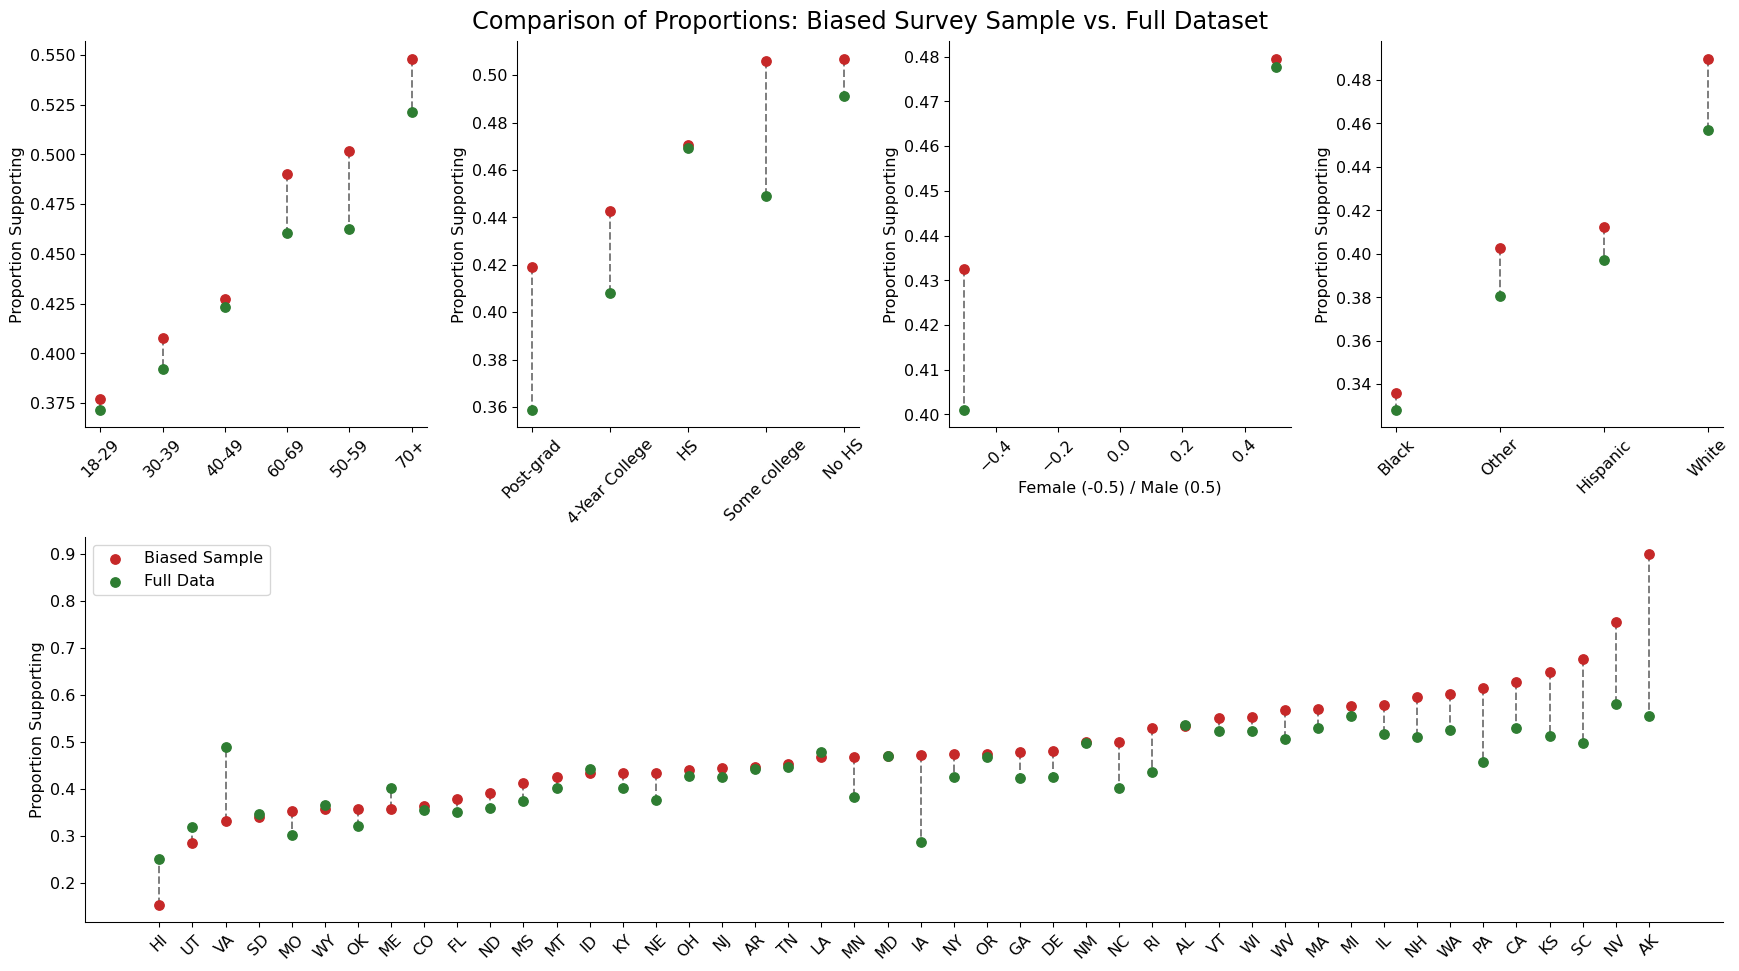

In [18]:
mosaic = """
    ABCD
    EEEE
    """

fig = plt.figure(layout="constrained", figsize=(18, 10))
ax_dict = fig.subplot_mosaic(mosaic)


def plot_var(var, ax):
    a = (
        cces_df.groupby(var, observed=False)[["abortion"]]
        .mean()
        .rename({"abortion": "share"}, axis=1)
        .reset_index()
    )
    b = (
        cces_all_df.groupby(var, observed=False)[["abortion"]]
        .mean()
        .rename({"abortion": "share_census"}, axis=1)
        .reset_index()
    )
    a = a.merge(b).sort_values("share")
    ax_dict[ax].vlines(a[var], a.share, a.share_census, color="gray", linestyle="--")
    ax_dict[ax].scatter(a[var], a.share, color="#C62828", s=50, zorder=3, label="Biased Sample")
    ax_dict[ax].scatter(
        a[var], a.share_census, color="#2E7D32", s=50, zorder=3, label="Full Data"
    )
    ax_dict[ax].set_ylabel("Proportion Supporting")
    ax_dict[ax].tick_params(axis='x', rotation=45)


plot_var("age", "A")
plot_var("edu", "B")
plot_var("male", "C")
plot_var("eth", "D")
plot_var("state", "E")

ax_dict["E"].legend(fontsize=12)
ax_dict["C"].set_xlabel("Female (-0.5) / Male (0.5)")
plt.suptitle(
    "Comparison of Proportions: Biased Survey Sample vs. Full Dataset", fontsize=18
);

The bias is systematic. The biased sample consistently under-represents certain demographic profiles, leading to aggregate distortions.

## Quantifying the Aggregate Bias


In [19]:
def get_se_bernoulli(p, n):
    return np.sqrt(p * (1 - p) / n)


sample_biased = {
    "data": "Biased Sample",
    "mean": np.mean(cces_df["abortion"].astype(float)),
    "se": get_se_bernoulli(np.mean(cces_df["abortion"].astype(float)), len(cces_df)),
    "n": len(cces_df),
}

sample_full = {
    "data": "Full Dataset",
    "mean": np.mean(cces_all_df["abortion"].astype(float)),
    "se": get_se_bernoulli(np.mean(cces_all_df["abortion"].astype(float)), len(cces_all_df)),
    "n": len(cces_all_df),
}

pd.DataFrame([sample_full, sample_biased]).set_index("data")

,mean,se,n
data,,,
Full Dataset,0.434051,0.002113,55035
Biased Sample,0.467400,0.007056,5000


::: {.callout-important}
### A 3% Gap Matters

A 3 percentage point difference in a national survey is a substantial error when the difference is due to preventable bias. In a close election, this margin decides outcomes. In market research, it redirects millions in advertising spend. MRP offers a principled correction when we know the population structure.
:::

# Fitting the Regression Model

## Aggregating to Demographic Cells

To fit a binomial regression efficiently, we first aggregate the individual-level survey responses into demographic cells. Each cell is a unique combination of (state, ethnicity, gender, age, education), and we count the number of respondents and the number supporting the policy within each cell.


In [20]:
model_df = (
    cces_df.groupby(["state", "eth", "male", "age", "edu"], observed=False)
    .agg({"caseid": "nunique", "abortion": "sum"})
    .reset_index()
    .sort_values("abortion", ascending=False)
    .rename({"caseid": "n"}, axis=1)
    .merge(statelevel_predictors_df, left_on="state", right_on="state", how="left")
)
model_df["abortion"] = model_df["abortion"].astype(int)
model_df["n"] = model_df["n"].astype(int)

print(f"Aggregated data: {len(model_df):,} demographic cells")
print(f"Total respondents: {model_df['n'].sum():,}")
print(f"Cells with 0 respondents: {(model_df['n'] == 0).sum():,}")
model_df.head(10)

Aggregated data: 11,040 demographic cells
Total respondents: 5,000
Cells with 0 respondents: 8,952


,state,eth,male,age,edu,n,abortion,repvote,region
0,ID,White,0.5,70+,4-Year College,24,17,0.683102,West
1,TN,White,0.5,60-69,HS,21,13,0.636243,South
2,CO,White,0.5,70+,Post-grad,21,12,0.473167,West
3,CO,White,0.5,60-69,Some college,22,11,0.473167,West
4,WV,White,0.5,60-69,Some college,15,11,0.721611,South
5,WV,White,0.5,50-59,HS,13,10,0.721611,South
6,CO,White,0.5,70+,Some college,18,10,0.473167,West
7,ID,White,0.5,70+,Some college,19,10,0.683102,West
8,WV,White,0.5,70+,Some college,15,10,0.721611,South
9,ID,White,0.5,50-59,Some college,11,9,0.683102,West


::: {.callout-tip}
### Why Aggregate?

Aggregation transforms the data from individual Bernoulli trials (one row per respondent) to binomial counts (one row per demographic cell). The statistical information is identical, but the computational savings are enormous: fitting a binomial model on ~3,000 cells is far faster than fitting a Bernoulli model on ~5,000 individuals, and the efficiency gain grows with larger surveys.
:::

## Exploratory Model: Fixed Effects

Before fitting the hierarchical model, we fit a simpler fixed-effects model to explore the data structure and assess basic patterns of variation:


In [21]:
formula_base = "p(abortion, n) ~ C(state) + C(eth) + C(edu) + male + repvote"

base_model = bmb.Model(formula_base, model_df, family="binomial")
result_base = base_model.fit(
    random_seed=100,
    target_accept=0.95,
    inference_method="numpyro",
    num_chains=4,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Default computed for conditional variable: eth


Default computed for unspecified variable: edu, male, repvote, state


Default computed for conditional variable: edu


Default computed for unspecified variable: eth, male, repvote, state


Default computed for conditional variable: state


Default computed for unspecified variable: edu, eth, male, repvote


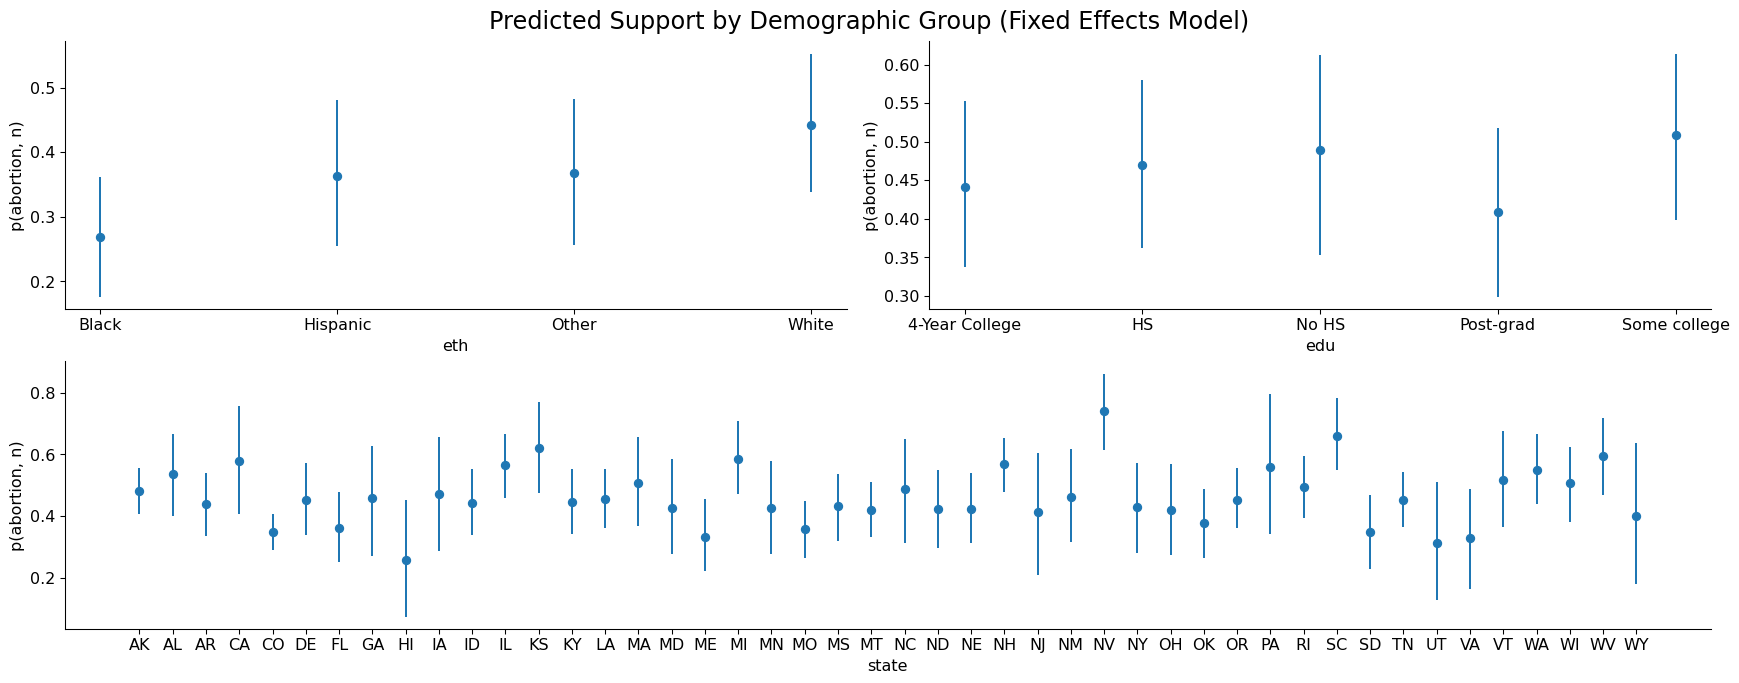

In [22]:
mosaic = """
AABB
CCCC
"""

fig = plt.figure(layout="constrained", figsize=(18, 7))
axs = fig.subplot_mosaic(mosaic)

bmb.interpret.plot_predictions(base_model, result_base, "eth", ax=axs["A"])
bmb.interpret.plot_predictions(base_model, result_base, "edu", ax=axs["B"])
bmb.interpret.plot_predictions(base_model, result_base, "state", ax=axs["C"])
plt.suptitle("Predicted Support by Demographic Group (Fixed Effects Model)", fontsize=18);

The `plot_comparisons` function lets us examine how the difference between ethnic groups varies across age and education levels. This reveals whether demographic effects are additive or interact:


Default computed for conditional variable: age, edu


Default computed for unspecified variable: male, repvote, state


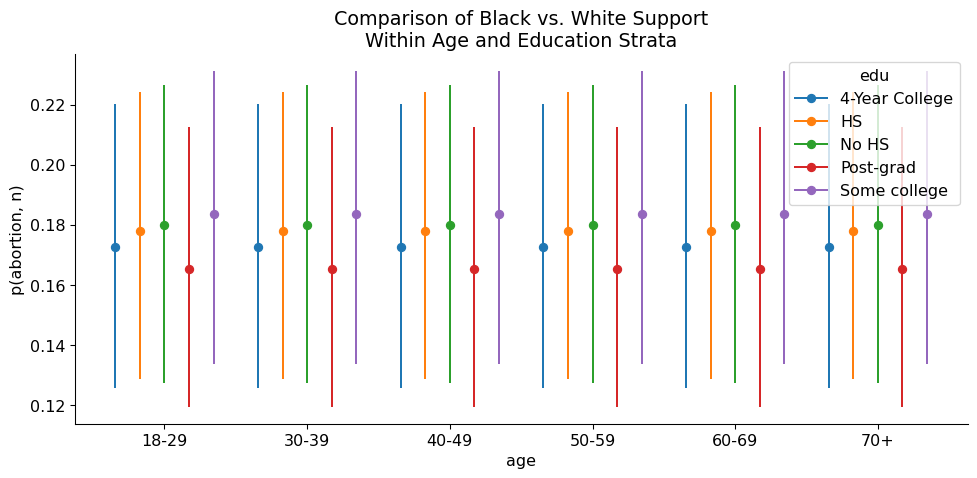

In [23]:
fig, ax = bmb.interpret.plot_comparisons(
    model=base_model,
    idata=result_base,
    contrast={"eth": ["Black", "White"]},
    conditional=["age", "edu"],
    comparison_type="diff",
    subplot_kwargs={"main": "age", "group": "edu"},
    fig_kwargs={"figsize": (12, 5), "sharey": True},
    legend=True,
)
ax[0].set_title(
    "Comparison of Black vs. White Support\nWithin Age and Education Strata"
);

In [24]:
bmb.interpret.comparisons(
    model=base_model,
    idata=result_base,
    contrast={"edu": ["Post-grad", "No HS"]},
    conditional={"eth": ["Black", "White"], "state": ["NY", "CA", "ID", "VA"]},
    comparison_type="diff",
)

Default computed for unspecified variable: male, repvote


,term,estimate_type,value,eth,state,male,repvote,estimate,lower_3.0%,upper_97.0%
0,edu,diff,"(Post-grad, No HS)",Black,CA,0.0,0.530191,0.076576,0.001871,0.159316
1,edu,diff,"(Post-grad, No HS)",Black,ID,0.0,0.530191,0.065617,-0.002249,0.138209
2,edu,diff,"(Post-grad, No HS)",Black,NY,0.0,0.530191,0.064058,0.001890,0.142652
3,edu,diff,"(Post-grad, No HS)",Black,VA,0.0,0.530191,0.050642,-0.003664,0.112990
4,edu,diff,"(Post-grad, No HS)",White,CA,0.0,0.530191,0.076451,0.003433,0.158124
5,edu,diff,"(Post-grad, No HS)",White,ID,0.0,0.530191,0.080469,0.004153,0.166141
6,edu,diff,"(Post-grad, No HS)",White,NY,0.0,0.530191,0.079241,0.002499,0.164317
7,edu,diff,"(Post-grad, No HS)",White,VA,0.0,0.530191,0.071352,0.001576,0.154288


These exploratory results reveal meaningful variation across demographic strata. The differences between education levels are moderated by state and ethnicity --- suggesting that a model with interactions will better capture the data-generating process.

## The Hierarchical Model

The exploratory analysis motivates a multilevel model with random intercepts for each demographic grouping and key interactions. The model specification is:

$$
\Pr(y_i = 1) = \text{logit}^{-1}\bigl(
\alpha_{s[i]}^{\text{state}}
+ \alpha_{r[i]}^{\text{eth}}
+ \alpha_{e[i]}^{\text{edu}}
+ \beta^{\text{male}} \cdot \text{Male}_i
+ \beta^{\text{repvote}} \cdot \text{RepVote}_{s[i]}
+ \alpha_{g[i],r[i]}^{\text{male.eth}}
+ \alpha_{e[i],a[i]}^{\text{edu.age}}
+ \alpha_{e[i],r[i]}^{\text{edu.eth}}
\bigr)
$$

Each $\alpha$ term is a random intercept drawn from a shared distribution (normal with estimated variance). This produces **partial pooling**: groups with little data are shrunk toward the overall mean, while groups with abundant data retain their empirical estimates.


In [25]:
formula_hier = (
    "p(abortion, n) ~ male + repvote"
    " + (1 | state) + (1 | eth) + (1 | edu)"
    " + (1 | male:eth) + (1 | edu:age) + (1 | edu:eth)"
)

model_hierarchical = bmb.Model(formula_hier, model_df, family="binomial")
result = model_hierarchical.fit(
    draws=2000,
    random_seed=110,
    target_accept=0.95,
    inference_method="numpyro",
)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 54 divergences after tuning. Increase `target_accept` or reparameterize.


In [26]:
az.summary(
    result, var_names=["Intercept", "male", "1|edu", "1|eth", "repvote"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.152,0.446,-0.686,0.994,0.009,0.006,2589.0,2934.0,1.0
male,0.425,0.308,-0.164,1.019,0.007,0.007,2528.0,2702.0,1.0
1|edu[4-Year College],-0.038,0.149,-0.337,0.231,0.002,0.004,6190.0,5402.0,1.0
1|edu[HS],0.001,0.143,-0.276,0.278,0.002,0.004,5784.0,4817.0,1.0
1|edu[No HS],0.046,0.163,-0.233,0.381,0.002,0.005,6851.0,5888.0,1.0
1|edu[Post-grad],-0.053,0.154,-0.408,0.188,0.002,0.004,6136.0,5726.0,1.0
1|edu[Some college],0.045,0.150,-0.206,0.356,0.002,0.004,5754.0,5895.0,1.0
1|eth[Black],-0.214,0.346,-0.940,0.360,0.006,0.007,3701.0,3538.0,1.0
1|eth[Hispanic],-0.021,0.325,-0.663,0.639,0.006,0.008,4245.0,2812.0,1.0
1|eth[Other],0.010,0.338,-0.678,0.633,0.006,0.013,4315.0,3498.0,1.0


::: {.callout-note}
### Understanding the Formula

| Term | Role |
|:---|:---|
| `p(abortion, n)` | Binomial outcome: `abortion` successes out of `n` trials per cell |
| `male` | Fixed effect for gender (centered at 0) |
| `repvote` | Fixed effect for state-level Republican vote share |
| `(1 \| state)` | Random intercept per state --- captures state-level variation beyond `repvote` |
| `(1 \| eth)` | Random intercept per ethnicity group |
| `(1 \| edu)` | Random intercept per education level |
| `(1 \| male:eth)` | Random intercept for gender-ethnicity interaction |
| `(1 \| edu:age)` | Random intercept for education-age interaction |
| `(1 \| edu:eth)` | Random intercept for education-ethnicity interaction |

The random intercepts are drawn from normal distributions with *estimated* variance. Small groups are pulled toward the grand mean; large groups retain their observed values. This is partial pooling in action.
:::

We can inspect the model structure visually:


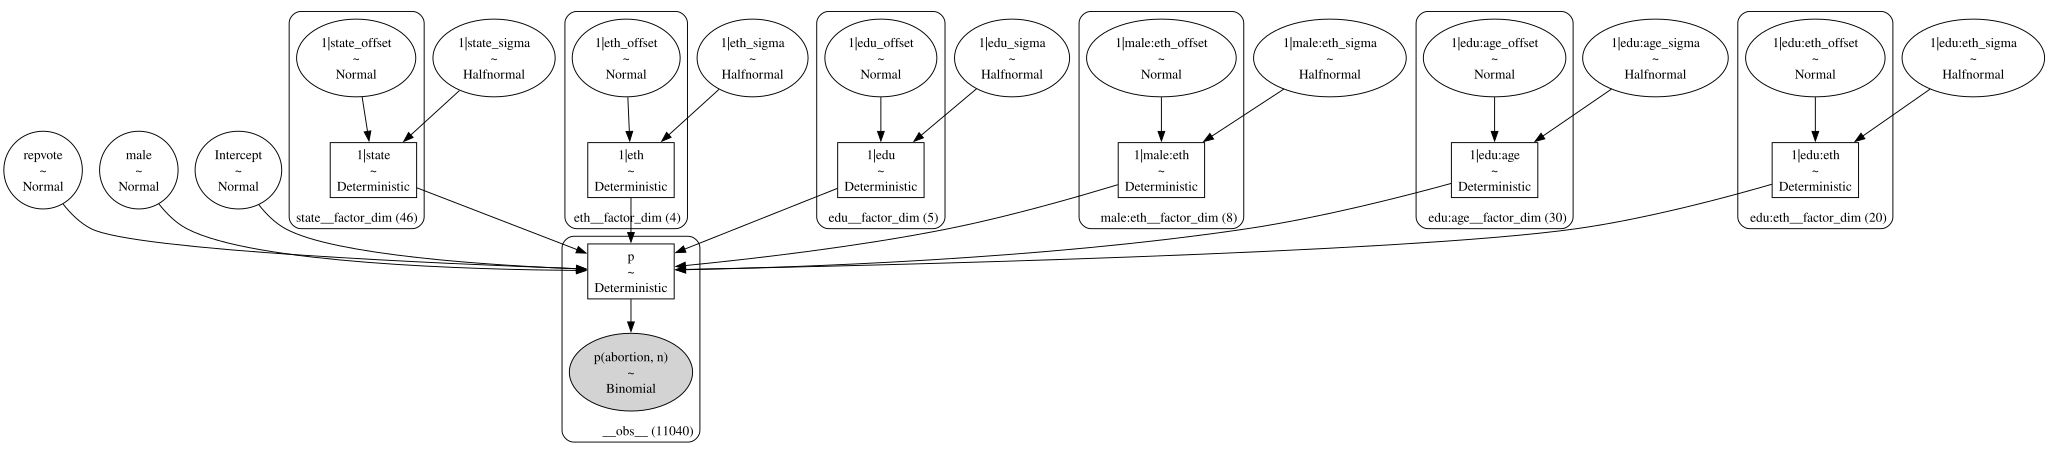

In [27]:
model_hierarchical.graph()

## Model Diagnostics

Before using the model for post-stratification, we verify that it fits the observed data adequately. The trace plot should show indications of healthy sampling with fuzzy caterpillar like line plots. 


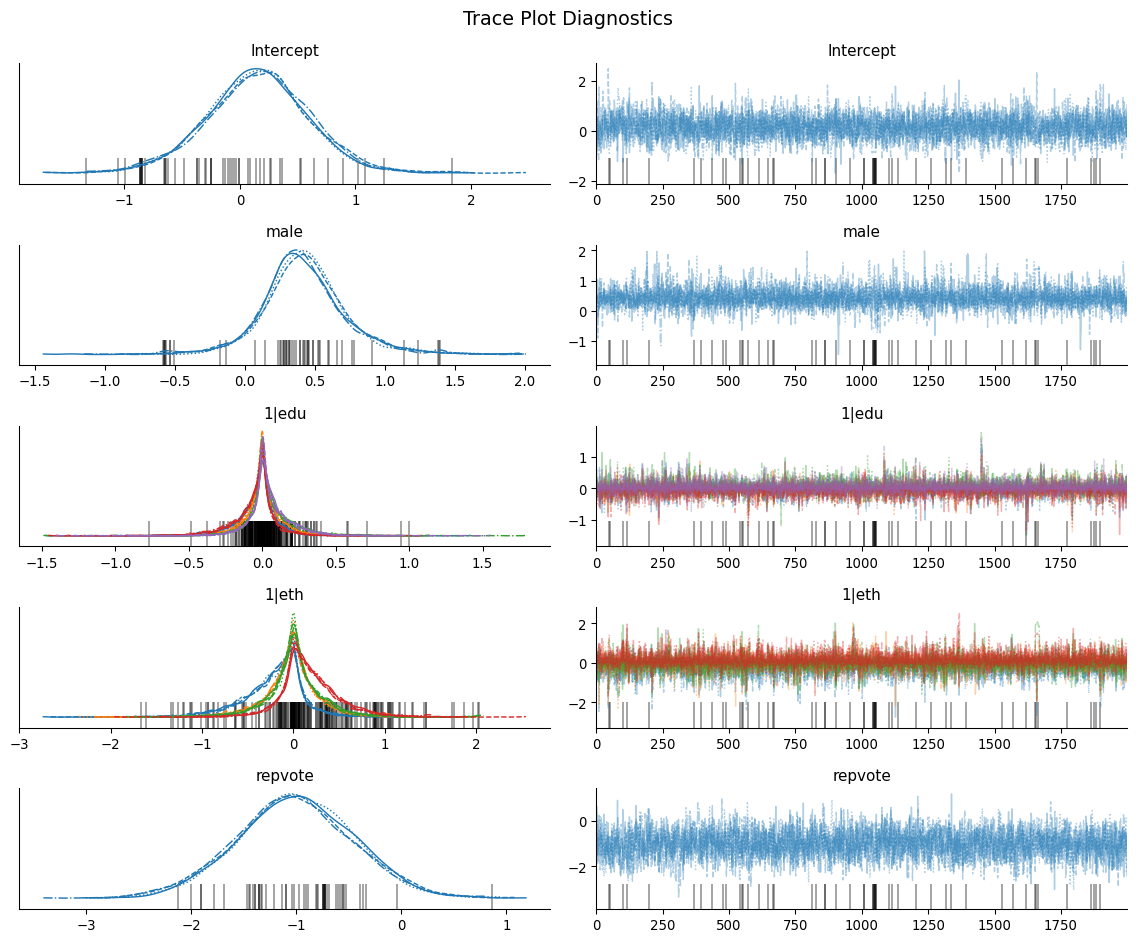

In [28]:
model_hierarchical.predict(result, kind="response")
ax = az.plot_trace(
    result, var_names=["Intercept", "male", "1|edu", "1|eth", "repvote"]
)
plt.suptitle("Trace Plot Diagnostics");
plt.tight_layout();

The posterior predictive check compares the empirical distribution of the outcome with distributions simulated from the posterior:


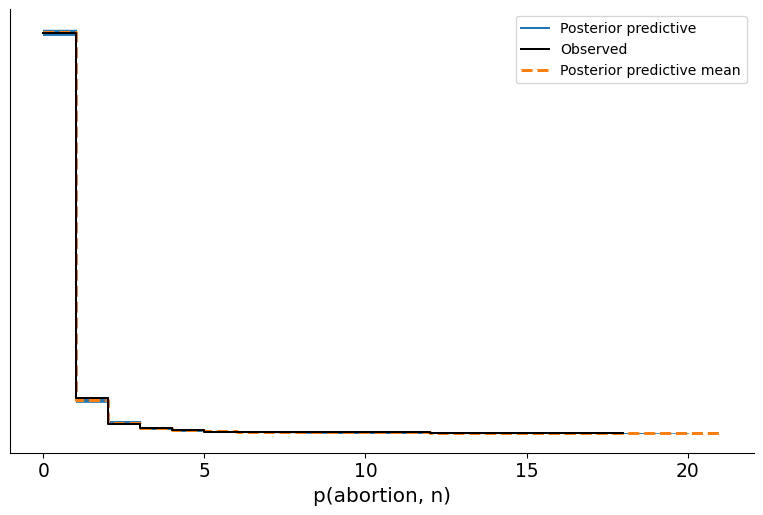

In [29]:
az.plot_ppc(result, num_pp_samples=500);

# Post-Stratification

We now turn to the second ingredient of the unifying identity: the cell weights $P(\text{cell}_j)$. The regression model has given us estimates of $E[Y \mid \text{cell}_j]$; the census will supply the correct $P(\text{cell}_j)$ to replace the sample's implicit proportions.

## Loading Census Population Data

The post-stratification frame is a census-derived dataset giving the population count for every demographic cell. Each cell is a unique combination of (state, ethnicity, gender, age, education):


In [30]:
poststrat_df = pd.read_csv("../../data/mr_p_poststrat_df.csv")
print(f"Post-stratification cells: {len(poststrat_df):,}")
print(f"Total population represented: {poststrat_df['n'].sum():,}")
poststrat_df.head()

Post-stratification cells: 12,000
Total population represented: 228,443,347


,state,eth,male,age,educ,n
0,AL,White,-0.5,18-29,No HS,23948
1,AL,White,-0.5,18-29,HS,59378
2,AL,White,-0.5,18-29,Some college,104855
3,AL,White,-0.5,18-29,4-Year College,37066
4,AL,White,-0.5,18-29,Post-grad,9378


## Preparing the Census Data for Prediction

We merge the census population counts with the state-level predictors (Republican vote share) and compute the **state-level population share** for each demographic cell. Crucially, the census frame drives this merge: we keep **all** census cells, including those with zero survey respondents. The hierarchical model can predict into unobserved cells via partial pooling --- this is one of MRP's key advantages over classical raking or direct estimation.


In [31]:
new_data = poststrat_df.merge(
    statelevel_predictors_df, left_on="state", right_on="state", how="left"
)
new_data.rename({"educ": "edu"}, axis=1, inplace=True)

# Census-driven merge: keep ALL census cells, not just those in the biased sample.
# The hierarchical model can predict into cells with zero survey respondents
# via partial pooling — this is a key advantage of MRP.
new_data = new_data.merge(
    model_df[["state", "eth", "male", "age", "edu"]].drop_duplicates(),
    how="left",
    on=["state", "eth", "male", "age", "edu"],
    indicator=True,
)
n_unobserved = (new_data["_merge"] == "left_only").sum()
print(f"Census cells with no survey respondents: {n_unobserved}")
new_data = new_data.drop(columns=["_merge"])

new_data = new_data.merge(
    new_data.groupby("state")
    .agg({"n": "sum"})
    .reset_index()
    .rename({"n": "state_total"}, axis=1)
)
new_data["state_percent"] = new_data["n"] / new_data["state_total"]
print(f"Prediction dataset: {len(new_data):,} cells")
new_data.head()

Census cells with no survey respondents: 960
Prediction dataset: 12,000 cells


,state,eth,male,age,edu,n,repvote,region,state_total,state_percent
0,AL,White,-0.5,18-29,No HS,23948,0.643741,South,3671705,0.006522
1,AL,White,-0.5,18-29,HS,59378,0.643741,South,3671705,0.016172
2,AL,White,-0.5,18-29,Some college,104855,0.643741,South,3671705,0.028558
3,AL,White,-0.5,18-29,4-Year College,37066,0.643741,South,3671705,0.010095
4,AL,White,-0.5,18-29,Post-grad,9378,0.643741,South,3671705,0.002554


::: {.callout-note}
### What Changed

The prediction dataset now includes **every demographic cell in the census**, not just those observed in our biased sample. The counts reflect the **census population** rather than the survey sample, and `state_percent` gives the fraction of each state's population in each cell. Cells that had no survey respondents will still receive predictions from the hierarchical model, which extrapolates via the random effects structure. This is precisely why MRP uses multilevel models: partial pooling lets us predict into sparse or empty cells without the estimates degenerating.
:::

## Reusable MRP Functions

Before applying MRP to our models, we define three reusable functions. Extracting these makes the post-stratification workflow modular: we can apply the same correction procedure to *any* fitted Bambi model, then compare how different model specifications affect the quality of the MRP correction.


In [32]:
def poststratify_by_state(
    model: bmb.Model,
    idata: az.InferenceData,
    new_data: pd.DataFrame,
    num_samples: int = 2000,
    model_type: str = "hierarchical",
) -> pd.DataFrame:
    """
    Compute state-level MRP estimates from a fitted model and census frame.

    For each state, generates posterior predictions on census-weighted
    demographic cells, then computes the weighted sum per draw. Credible
    intervals are taken from the distribution of draw-level state estimates
    (not from per-cell quantiles, which would overstate uncertainty).

    For hierarchical models (``model_type="hierarchical"``), unseen factor
    levels are handled via ``sample_new_groups=True``, which draws new group
    intercepts from the estimated population distribution. For fixed-effects
    models (``model_type="fixed_effects"``), unseen levels are filtered out
    and within-state population shares are recomputed — a warning is printed
    so the analyst sees which states are dropped.

    Parameters
    ----------
    model : bmb.Model
        A fitted Bambi binomial model.
    idata : az.InferenceData
        Posterior samples from model.fit().
    new_data : pd.DataFrame
        Census prediction frame with columns including state, state_percent,
        and the covariates used in the model formula.
    num_samples : int
        Number of posterior draws to extract.
    model_type : str
        Either ``"hierarchical"`` or ``"fixed_effects"``. Controls whether
        unseen factor levels are predicted via ``sample_new_groups=True``
        (hierarchical) or filtered out (fixed effects).

    Returns
    -------
    pd.DataFrame
        Columns: state, mrp_adjusted, mrp_lb, mrp_ub.
    """
    pred_data = new_data.copy()
    dropped = set()

    if model_type == "fixed_effects":
        # Fixed-effects model: filter out census cells whose categorical
        # levels were never seen during training.
        training_data = model.data
        for col in ["state", "eth", "edu"]:
            if col in training_data.columns and col in pred_data.columns:
                seen_levels = set(training_data[col].unique())
                unseen_mask = ~pred_data[col].isin(seen_levels)
                if unseen_mask.any():
                    unseen = set(pred_data.loc[unseen_mask, col].unique())
                    dropped.update(unseen)
                    pred_data = pred_data[~unseen_mask].copy()

        if dropped:
            print(
                f"  ⚠ Dropped {len(dropped)} unseen factor level(s) "
                f"not in training data: {sorted(dropped)}"
            )
            # Recompute state_percent within the filtered data
            state_totals = (
                pred_data.groupby("state")["n"]
                .sum()
                .reset_index()
                .rename(columns={"n": "state_total"})
            )
            pred_data = pred_data.drop(
                columns=["state_total", "state_percent"], errors="ignore"
            )
            pred_data = pred_data.merge(state_totals, on="state")
            pred_data["state_percent"] = pred_data["n"] / pred_data["state_total"]

    # For hierarchical models, sample_new_groups=True draws group
    # intercepts from the estimated population distribution, enabling
    # prediction for states/groups absent from the training sample.
    predict_kwargs = dict(data=pred_data, inplace=False, kind="response")
    if model_type == "hierarchical":
        predict_kwargs["sample_new_groups"] = True

    result_pred = model.predict(idata, **predict_kwargs)
    posterior = az.extract(result_pred, num_samples=num_samples)["p"]

    mrp_estimates = []
    for s in pred_data["state"].unique():
        idx = pred_data.index[pred_data["state"] == s].tolist()
        weights = pred_data.iloc[idx]["state_percent"].values

        # Weighted sum per draw, then summarise
        mrp_draws = (posterior[idx].values * weights[:, None]).sum(axis=0)

        mrp_estimates.append({
            "state": s,
            "mrp_adjusted": float(np.mean(mrp_draws)),
            "mrp_lb": float(np.quantile(mrp_draws, 0.025)),
            "mrp_ub": float(np.quantile(mrp_draws, 0.975)),
        })

    return pd.DataFrame(mrp_estimates)


def plot_mrp_evaluation(
    state_predicted: pd.DataFrame,
    title_suffix: str = "",
):
    """
    Two-panel MRP evaluation plot: accuracy (top) and uncertainty (bottom).

    States absent from the biased sample (NaN in raw_biased) are still
    plotted for MRP and census, but omitted from the raw scatter/vlines.

    Parameters
    ----------
    state_predicted : pd.DataFrame
        Must have columns: state, raw_biased, mrp_adjusted, census_share,
        raw_lb, raw_ub, mrp_lb, mrp_ub.
    title_suffix : str
        Appended to plot titles (e.g., "(Fixed Effects)").
    """
    fig, axs = plt.subplots(2, 1, figsize=(17, 10))
    ax, ax1 = axs

    # Subset with raw sample data (may exclude states absent from biased sample)
    has_raw = state_predicted.dropna(subset=["raw_biased"])

    # Top panel: accuracy
    ax.scatter(has_raw["state"], has_raw["raw_biased"],
               color="#C62828", label="Raw Biased Sample", s=40, zorder=3)
    ax.scatter(state_predicted["state"], state_predicted["mrp_adjusted"],
               color="#4527A0", label="MRP Adjusted", s=40, zorder=3)
    ax.scatter(state_predicted["state"], state_predicted["census_share"],
               color="#2E7D32", label="Census Ground Truth", s=40, zorder=3)
    ax.vlines(state_predicted["state"],
              state_predicted["mrp_adjusted"], state_predicted["census_share"],
              color="black", linestyles="--", alpha=0.5)
    ax.legend(fontsize=12)
    ax.set_xlabel("State")
    ax.set_ylabel("Proportion Supporting")
    ax.set_title(f"Post-Stratified Adjustment vs. Census Ground Truth {title_suffix}", fontsize=16)

    # Bottom panel: uncertainty
    ax1.scatter(has_raw["state"], has_raw["raw_biased"],
                color="#C62828", label="Raw Biased Sample", s=40, zorder=3)
    ax1.scatter(state_predicted["state"], state_predicted["mrp_adjusted"],
                color="#4527A0", label="MRP Adjusted", s=40, zorder=3)
    ax1.vlines(has_raw["state"],
               has_raw["raw_ub"], has_raw["raw_lb"],
               color="#C62828", alpha=0.6)
    ax1.vlines(state_predicted["state"],
               state_predicted["mrp_ub"], state_predicted["mrp_lb"],
               color="#4527A0", alpha=0.6)
    ax1.legend(fontsize=12)
    ax1.set_xlabel("State")
    ax1.set_ylabel("Proportion Supporting")
    ax1.set_title(f"Uncertainty: Raw Sample vs. MRP {title_suffix}", fontsize=16)

    return fig, axs


def compute_mrp_mae(state_predicted: pd.DataFrame, label: str = "") -> dict:
    """Compute mean absolute error of raw and MRP estimates vs. census.

    Raw MAE is computed only over states present in the biased sample.
    MRP MAE is computed over *all* states the model can predict.
    """
    n_states_mrp = state_predicted["mrp_adjusted"].notna().sum()
    has_raw = state_predicted.dropna(subset=["raw_biased"])
    n_states_raw = len(has_raw)

    raw_mae = np.abs(
        has_raw["raw_biased"] - has_raw["census_share"]
    ).mean()
    mrp_mae = np.abs(
        state_predicted["mrp_adjusted"] - state_predicted["census_share"]
    ).mean()
    reduction = (1 - mrp_mae / raw_mae) * 100

    print(f"--- {label} ---")
    print(f"  States covered (MRP): {n_states_mrp},  (raw sample): {n_states_raw}")
    print(f"  MAE (raw biased sample): {raw_mae:.4f}")
    print(f"  MAE (MRP adjusted):      {mrp_mae:.4f}")
    print(f"  Reduction in error:      {reduction:.1f}%")
    return {
        "model": label, "n_states_mrp": n_states_mrp,
        "n_states_raw": n_states_raw,
        "raw_mae": raw_mae, "mrp_mae": mrp_mae, "reduction_pct": reduction,
    }

::: {.callout-note}
### Why Functions?

Extracting post-stratification into reusable functions lets us separate two questions that MRP combines: **(1)** How well does the model estimate cell-level opinions? and **(2)** How much does census reweighting improve the aggregate? By applying the same `poststratify_by_state` function to different models, we can isolate the contribution of model specification from the contribution of the reweighting step.
:::

## Computing Shared Baselines

The raw biased sample proportion per state and the census ground truth are model-independent: they serve as the common reference for evaluating any MRP correction.


In [33]:
# --- Raw biased sample baseline ---
# This is what you'd report if you naively trusted the biased survey:
# just the sample proportion within each state, no model, no correction.
raw_biased_by_state = (
    cces_df.groupby("state")[["abortion"]]
    .agg(["mean", "count"])
    .droplevel(0, axis=1)
    .rename(columns={"mean": "raw_biased", "count": "n_respondents"})
    .reset_index()
)

# Standard error for binomial proportion (for approximate CIs)
raw_biased_by_state["raw_se"] = np.sqrt(
    raw_biased_by_state["raw_biased"]
    * (1 - raw_biased_by_state["raw_biased"])
    / raw_biased_by_state["n_respondents"]
)
raw_biased_by_state["raw_lb"] = raw_biased_by_state["raw_biased"] - 1.96 * raw_biased_by_state["raw_se"]
raw_biased_by_state["raw_ub"] = raw_biased_by_state["raw_biased"] + 1.96 * raw_biased_by_state["raw_se"]

# --- Census ground truth ---
census_ground_truth = (
    cces_all_df.groupby("state")[["abortion"]]
    .mean()
    .reset_index()
    .rename(columns={"abortion": "census_share"})
)

## Assembling MRP Results

A small helper merges MRP estimates with the shared baselines:


In [34]:
def build_mrp_comparison(mrp_df, raw_biased_by_state, census_ground_truth):
    """Merge MRP estimates with raw biased baseline and census ground truth.

    Uses left joins from the MRP frame so that states predicted by the
    hierarchical model but absent from the biased sample are retained
    (with NaN for raw_biased).
    """
    return (
        mrp_df
        .merge(raw_biased_by_state[["state", "raw_biased", "raw_lb", "raw_ub"]],
               on="state", how="left")
        .merge(census_ground_truth, on="state", how="left")
        .sort_values("mrp_adjusted")
    )

# Evaluating the Correction

We now apply MRP to both the fixed-effects model and the hierarchical model. The raw biased sample baseline is the same for both --- it's what a naive analyst would report by averaging survey responses without any modeling or correction. The two MRP corrections differ only in the model used to estimate cell-level proportions.

## MRP with the Fixed-Effects Model

The fixed-effects model uses `C(state) + C(eth) + C(edu)` --- independent dummy variables with no information sharing across groups. This creates an immediate practical problem: if the biased sample is missing any states entirely, the model has no coefficient for those states and **cannot generate predictions** for their census cells. The function handles this by dropping unseen levels and recomputing within-state population shares, but the states themselves are lost from the MRP output.

This is already a powerful argument for hierarchical models: a random-effects specification with `(1 | state)` can predict into new states by drawing from the group-level distribution.


In [35]:
mrp_base = poststratify_by_state(base_model, result_base, new_data, model_type="fixed_effects")
state_predicted_base = build_mrp_comparison(mrp_base, raw_biased_by_state, census_ground_truth)

  ⚠ Dropped 4 unseen factor level(s) not in training data: ['AZ', 'CT', 'IN', 'TX']


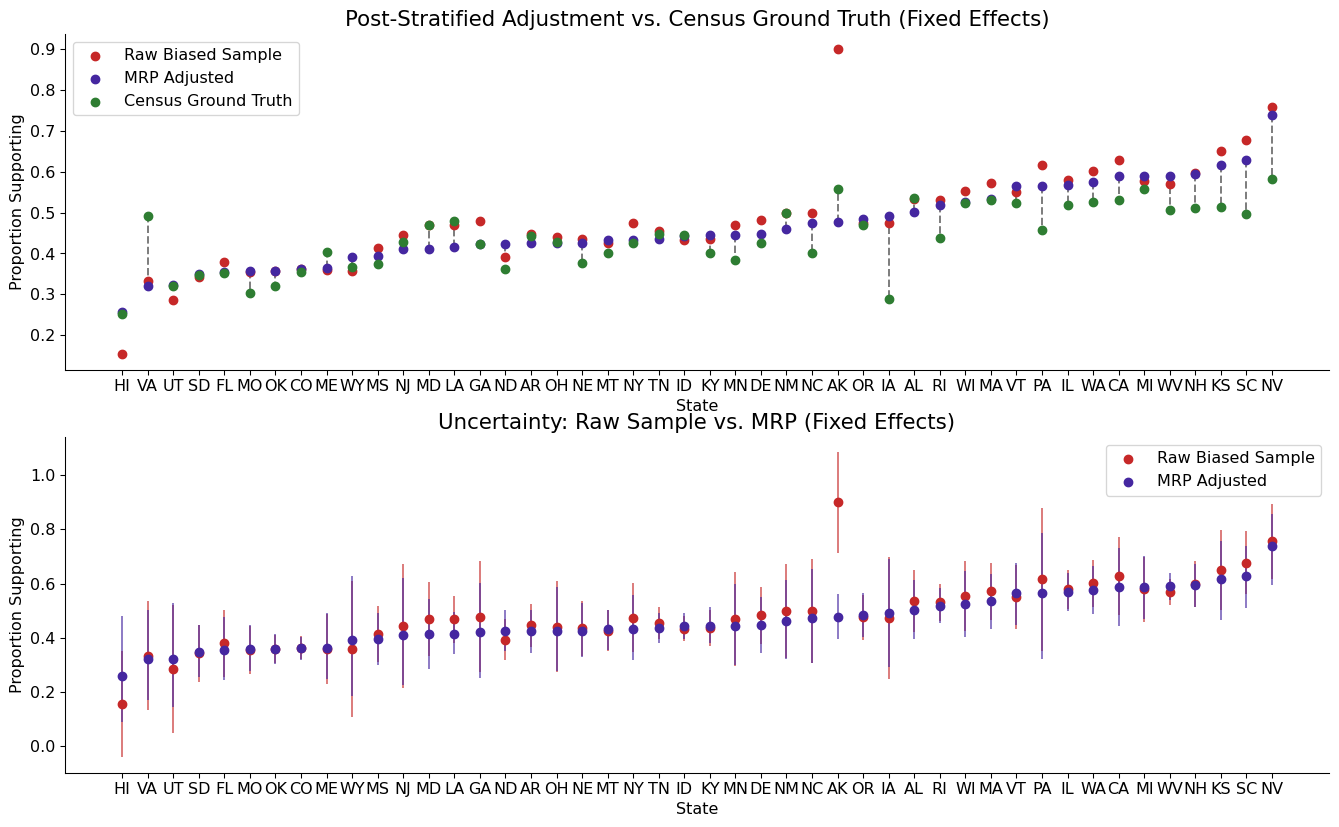

In [36]:
plot_mrp_evaluation(state_predicted_base, title_suffix="(Fixed Effects)");

In [37]:
mae_base = compute_mrp_mae(state_predicted_base, label="Fixed Effects Model")

--- Fixed Effects Model ---
  States covered (MRP): 46,  (raw sample): 46
  MAE (raw biased sample): 0.0619
  MAE (MRP adjusted):      0.0485
  Reduction in error:      21.6%


## MRP with the Hierarchical Model

The hierarchical model uses random intercepts `(1 | state) + (1 | eth) + (1 | edu)` plus interaction terms. Partial pooling lets it borrow strength across similar groups and predict sensibly into unobserved cells. Because `poststratify_by_state` detects the group-specific terms, it automatically passes `sample_new_groups=True` to the predict call — drawing new group intercepts from the estimated population distribution for any states absent from the biased sample. No states are dropped.


In [38]:
mrp_hier = poststratify_by_state(model_hierarchical, result, new_data, model_type="hierarchical")
state_predicted_hier = build_mrp_comparison(mrp_hier, raw_biased_by_state, census_ground_truth)

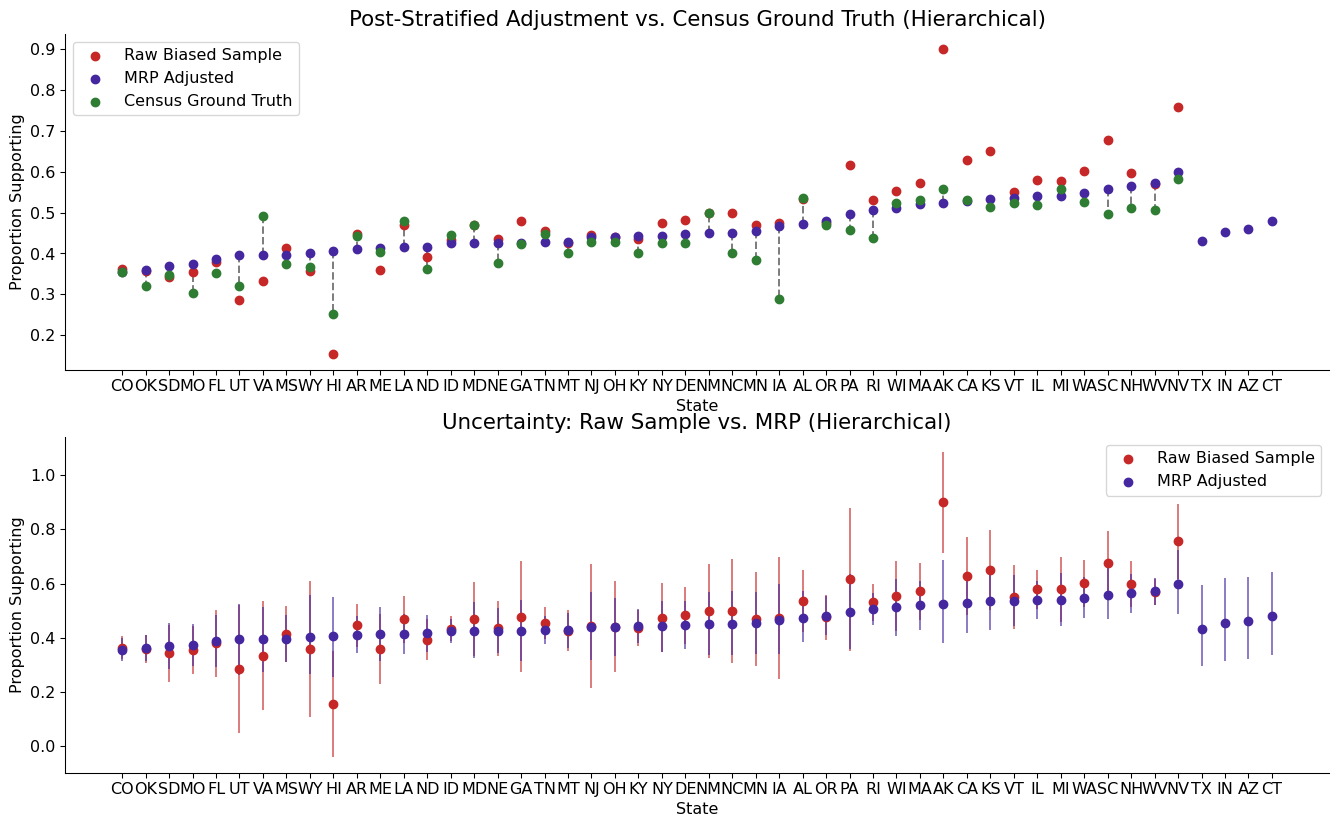

In [39]:
plot_mrp_evaluation(state_predicted_hier, title_suffix="(Hierarchical)");

In [40]:
mae_hier = compute_mrp_mae(state_predicted_hier, label="Hierarchical Model")

--- Hierarchical Model ---
  States covered (MRP): 50,  (raw sample): 46
  MAE (raw biased sample): 0.0619
  MAE (MRP adjusted):      0.0404
  Reduction in error:      34.7%


## Comparing Model Specifications

The two models use the same census weights and the same post-stratification procedure. The only difference is the quality of the cell-level predictions feeding into the reweighting step. Note that the fixed-effects model may cover *fewer states* than the hierarchical model because it cannot predict into states absent from the biased sample.


In [41]:
n_states_base = len(state_predicted_base)
n_states_hier = len(state_predicted_hier)
print(f"States covered — Fixed Effects: {n_states_base}, Hierarchical: {n_states_hier}")

comparison_df = pd.DataFrame([mae_base, mae_hier])
comparison_df

States covered — Fixed Effects: 46, Hierarchical: 50


,model,n_states_mrp,n_states_raw,raw_mae,mrp_mae,reduction_pct
0,Fixed Effects Model,46,46,0.061898,0.048537,21.584856
1,Hierarchical Model,50,46,0.061898,0.040396,34.737903


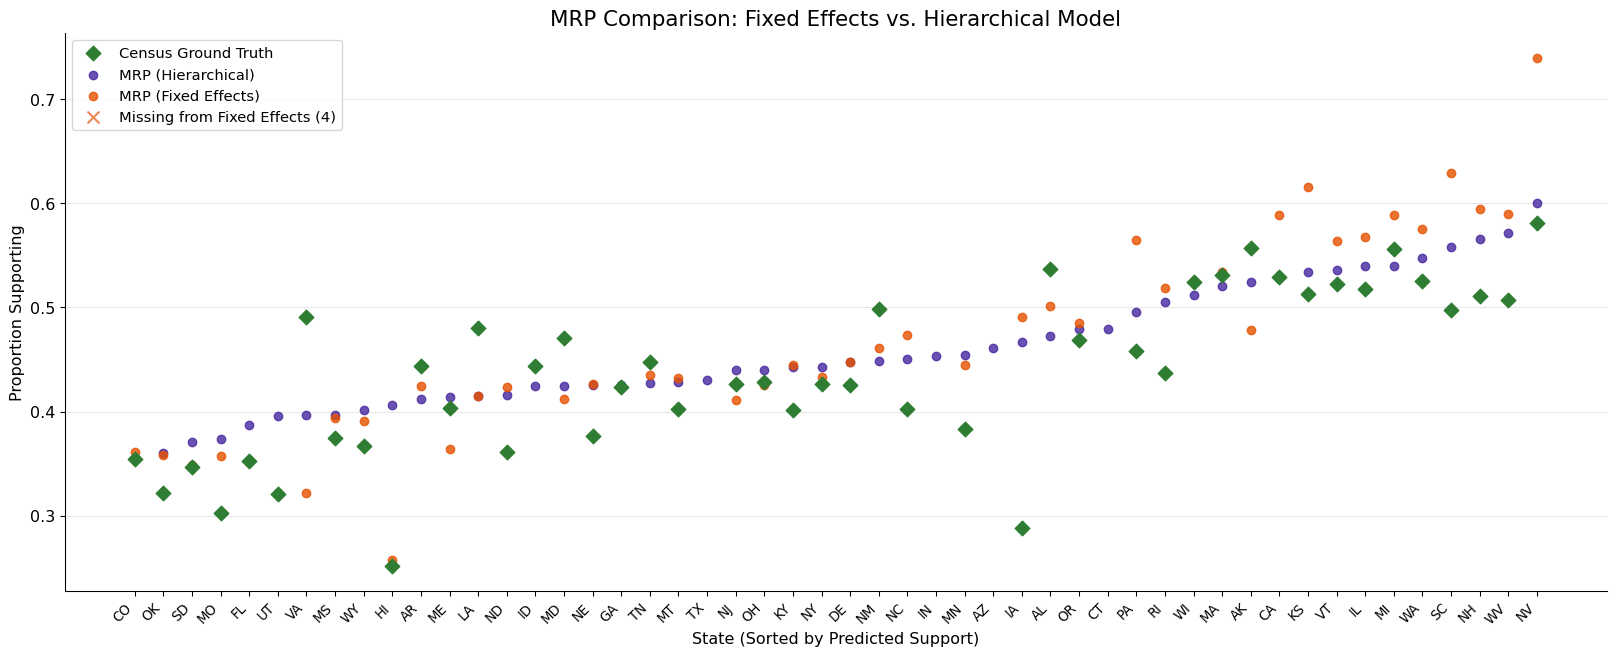

In [42]:
import numpy as np

fig, ax = plt.subplots(figsize=(17, 7))

# 1. Establish the shared horizontal order and coordinate system
state_order = state_predicted_hier["state"].values
x_coords = np.arange(len(state_order))
state_to_x = {s: i for i, s in enumerate(state_order)}

# Use hierarchical ordering as the master index
hier_indexed = state_predicted_hier.set_index("state")

# 2. Plot Census Ground Truth (Diamonds)
ax.scatter(x_coords, hier_indexed.loc[state_order, "census_share"],
           color="#2E7D32", label="Census Ground Truth", s=60, zorder=4, marker="D")

# 3. Plot Hierarchical MRP (Purple dots)
ax.scatter(x_coords, hier_indexed.loc[state_order, "mrp_adjusted"],
           color="#4527A0", label="MRP (Hierarchical)", s=40, zorder=3, alpha=0.8)

# 4. Fixed-effects: map states to their specific integer positions
base_indexed = state_predicted_base.set_index("state")
common_states = [s for s in state_order if s in base_indexed.index]
common_x = [state_to_x[s] for s in common_states]

ax.scatter(common_x, base_indexed.loc[common_states, "mrp_adjusted"],
           color="#E65100", label="MRP (Fixed Effects)", s=40, zorder=3, alpha=0.8)

# 5. Mark missing states (Orange X's)
missing_states = [s for s in state_order if s not in base_indexed.index]
if missing_states:
    missing_x = [state_to_x[s] for s in missing_states]
    missing_y = hier_indexed.loc[missing_states, "census_share"]
    ax.scatter(missing_x, missing_y,
               color="#E65100", marker="x", s=80, zorder=5, alpha=0.7,
               label=f"Missing from Fixed Effects ({len(missing_states)})")

# 6. Apply formatting: map the integer positions back to State names
ax.set_xticks(x_coords)
ax.set_xticklabels(state_order, rotation=45, ha='right', fontsize=10)

ax.legend(fontsize=11, loc='upper left')
ax.set_title("MRP Comparison: Fixed Effects vs. Hierarchical Model", fontsize=16)
ax.set_xlabel("State (Sorted by Predicted Support)")
ax.set_ylabel("Proportion Supporting")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

::: {.callout-important}
### Model Quality Matters

The comparison reveals that MRP effectiveness depends on *both* the reweighting step and the model that generates cell-level predictions. The hierarchical model outperforms for several reasons:

1. **Coverage**: Fixed-effects models cannot predict into states (or other factor levels) absent from the sample. With biased sampling, some states may have zero respondents --- and those states are simply lost. The hierarchical model covers all states by drawing on the group-level distribution.
2. **Partial pooling** lets the hierarchical model estimate cells with few or zero respondents by borrowing from similar cells, whereas fixed effects have no mechanism for this.
3. **Interaction terms** like `(1 | edu:age)` capture systematic variation that an additive fixed-effects model misses entirely.
4. **Regularisation** via the hierarchical priors prevents overfitting on noisy small-cell estimates.

Post-stratification is not *just* about reweighting --- it uses the model's cell-level predictions as inputs. Better predictions produce better corrections, regardless of how accurate the census weights are.
:::

# Exercises

::: {.callout-caution}
### Exercise 1: Varying the Bias

Modify the sampling weights in the biased sample creation step. What happens to the MRP correction when:

- The bias is *milder* (e.g., reduce the weight multipliers)?
- The bias operates along a dimension *not included* in the model (e.g., bias by income, which we don't model)?

When does MRP succeed, and when does it fail?
:::

::: {.callout-caution}
### Exercise 2: Model Specification

We've compared fixed effects and the full hierarchical model. Now try intermediate specifications --- e.g., random intercepts without interaction terms, or a model with `(1 | state)` but fixed effects for ethnicity and education. Use `poststratify_by_state` and `compute_mrp_mae` to evaluate each, building a table of how MRP accuracy varies with model complexity. You might also use `az.compare()` with LOO to formally compare the models.
:::

::: {.callout-caution}
### Exercise 3: Subgroup Estimates

Instead of state-level estimates, compute MRP-adjusted estimates for:

- **Age groups** within states
- **Education levels** nationally
- **Ethnic groups** within regions

How does the correction vary across subgroups? Which subgroups benefit most from post-stratification?
:::

::: {.callout-caution}
### Exercise 4: Prior Sensitivity

The hierarchical model uses Bambi's default priors. Experiment with:

- Tighter priors on the random effect variances (limiting partial pooling)
- Wider priors (allowing more between-group variation)

How sensitive are the MRP-adjusted estimates to prior specification?
:::

# Summary and Key Takeaways

## What We've Learned

1. **Regression automatically stratifies** across the covariates in the model, weighted by their prevalence in the training data. This is its power and its vulnerability.

2. **Biased samples produce biased estimates**, even when the regression model is correctly specified. The model faithfully adjusts to the wrong population weights.

3. **Post-stratification corrects this** by replacing sample composition with known population composition. In the language of the unifying identity, the model estimates $E[Y \mid \text{cell}_j]$ and the census supplies the correct $P(\text{cell}_j)$. The model learns *what people in each demographic cell think*; the census tells us *how many people are in each cell*.

4. **Multilevel models are essential** for MRP because they provide partial pooling across the thousands of demographic cells. Without hierarchical structure, cells with zero respondents would have no estimate.

5. **Bayesian inference** propagates uncertainty naturally through the MRP pipeline. Credible intervals for state-level estimates are a byproduct of the posterior, not an additional approximation.

6. **Model specification matters.** Post-stratification uses cell-level predictions as inputs, so a model that estimates these poorly will produce poor corrections regardless of how accurate the census weights are. Hierarchical models with partial pooling consistently outperform fixed-effects alternatives for MRP.

## When to Use MRP

MRP is most effective when:

- **Sample bias is driven by demographics** that you can measure and model
- **Census or administrative data** are available for the target population
- **You need small-area estimates** (e.g., state-level from a national survey)
- **The survey sample is too small** for reliable direct estimation within subgroups
- **You want principled uncertainty quantification** rather than ad-hoc weighting adjustments

## Cautions

- MRP **cannot correct for bias along unmeasured dimensions**. If non-response is driven by the outcome itself (e.g., people ashamed of their views refuse to participate), demographic reweighting won't help.
- The **choice of strata is consequential**. Too few dimensions may miss important sources of bias; too many may create cells that the model cannot estimate reliably.
- Post-stratification assumes the model **generalises correctly** to all census cells, including those with zero survey respondents. The partial pooling of hierarchical models helps, but doesn't eliminate this assumption.
- MRP is a **correction, not a cure**. It reduces bias but cannot eliminate it. Good survey design remains the first line of defence.

::: {.callout-warning}
### The Ecological Fallacy: Why Direction Matters

MRP works because it reasons *upward*: estimating individual-level (or cell-level) behaviour and then aggregating to the population using known weights. The reverse direction --- inferring individual-level relationships from aggregate data --- is the **ecological fallacy**, and it is dangerous.

To see why, consider a finding that states with higher average income tend to vote for left-leaning candidates. It is tempting to conclude that *rich individuals* vote left. But the aggregate correlation can be entirely driven by composition: wealthy states may have large urban populations that vote left for reasons unrelated to personal income, while within any given state, higher-income individuals may vote right. The aggregate pattern and the individual pattern can point in opposite directions.

MRP avoids this trap by construction. The multilevel model estimates $E[Y \mid \text{cell}_j]$ --- a cell-level quantity grounded in individual responses --- and the post-stratification step aggregates these estimates using population weights. At no point do we infer individual behaviour from group-level summaries. The law of total expectation runs from cells to populations, not the other way around. This asymmetry is not incidental; it is what makes the method principled.

The lesson: **aggregation with known weights is safe; disaggregation by assumption is not.** Whenever you are tempted to read individual-level conclusions from aggregate patterns, ask whether you have the cell-level data to support the claim --- or whether you are merely projecting the population pattern downward.
:::

## The Elephant is Everywhere

We opened with Basu's elephant parable: the statistician's scales were perfectly calibrated, but the sampling mechanism was fatally biased. MRP is the corrective --- even with a non-representative sample, knowledge of the true population structure lets us adjust our estimates.

The lesson extends far beyond elephants. Every convenience sample is a biased sample. Every online survey is a convenience sample. Every policy decision based on unweighted survey data risks serving the *respondents* rather than the *population*. It's not an exaggeration to say that the fates of entire nations can hang on decisions made from poorly understood sampling procedures.

Multilevel regression and post-stratification is an apt tool for making the adjustments required and guiding decision-makers in crucial policy choices --- but it should be used carefully, and with full awareness of what it can and cannot correct.

# References

::: {#refs}
:::

# Session Info


In [43]:
%load_ext watermark
%watermark -n -u -v -w -p arviz,bambi,numpy,nutpie,pymc,pytensor

Last updated: Wed, 11 Feb 2026

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.8.0

arviz   : 0.23.0
bambi   : 0.16.0
numpy   : 2.3.5
nutpie  : 0.16.4
pymc    : 5.27.0
pytensor: 2.36.1

Watermark: 2.6.0

